In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
store = pd.read_csv("../data/store.csv")

C:\Users\vighn\AppData\Local\Temp\ipykernel_14640\801007824.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


In [3]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Store:", store.shape)

Train: (1017209, 9)
Test: (41088, 8)
Store: (1115, 10)


In [4]:
print(train.columns.tolist())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


In [5]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [ ]:
#Why are we doing this? -> before it was just a text for python now it understands it as a date.
train["Date"] = pd.to_datetime(train["Date"])

In [8]:
print(train["Date"].dtype)

datetime64[us]


In [ ]:
#Now we'll check whether any data is missing. As no value is missing 
#So we don't need to do any missing-value imputation for train.
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [ ]:
#our sales data has no missing values, but store.csv has missing values in some store characteristics:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [11]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [12]:
zero_sales = (train["Sales"] == 0).sum()

print("Zero-sales records:", zero_sales)

Zero-sales records: 172871


In [ ]:
# 1,017,209 total records
#         │
#         ├── 172,817 zero sales
#         │       │
#         │       └── 172,817 closed
#         │
#         └── remaining records with sales

zero_sales_open = train[train["Sales"] == 0]["Open"].value_counts()

print(zero_sales_open)

Open
0    172817
1        54
Name: count, dtype: int64


In [ ]:
      # Now we know:

# Store status	   Records
# Open	           844,392
# Closed	       172,817
# Total   	       1,017,209

train["Open"].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [ ]:
## 2. Exploratory Data Analysis

### 2.1 Sales by Day of Week

# We analyze sales patterns across the days of the week using only records where stores were open.

open_sales = train[train["Open"] == 1]

daily_sales = open_sales.groupby("DayOfWeek")["Sales"].mean()

print(daily_sales)

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64


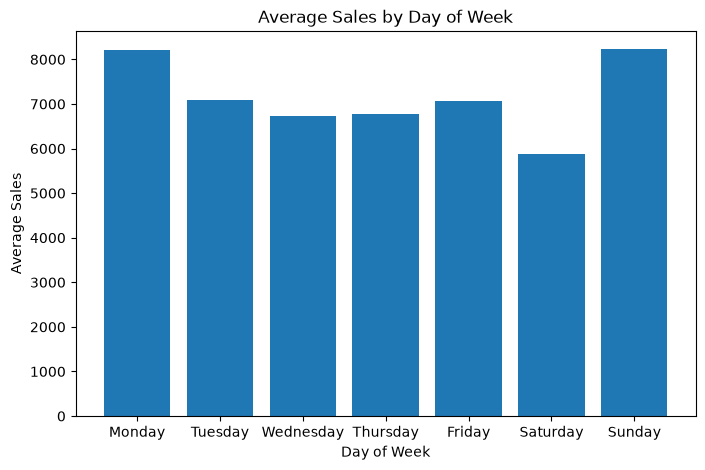

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(daily_sales.index, daily_sales.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")

plt.xticks(
    range(1, 8),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.show()

In [17]:
promo_sales = open_sales.groupby("Promo")["Sales"].mean()

print(promo_sales)

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


In [18]:
### 2.2 Sales Trend Over Time
daily_total_sales = open_sales.groupby("Date")["Sales"].sum()

print(daily_total_sales.head())

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64


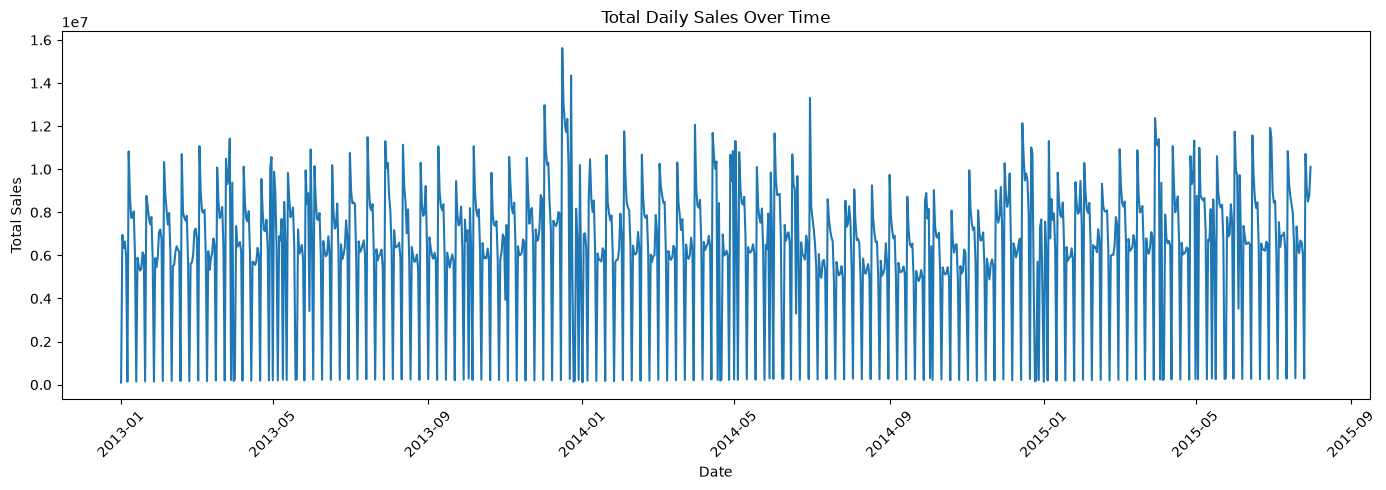

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(daily_total_sales.index, daily_total_sales.values)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Total Daily Sales Over Time")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
weekly_sales = daily_total_sales.resample("W").sum()

print(weekly_sales.head())

Date
2013-01-06    26129335
2013-01-13    49275222
2013-01-20    34377765
2013-01-27    46040169
2013-02-03    38466029
Freq: W-SUN, Name: Sales, dtype: int64


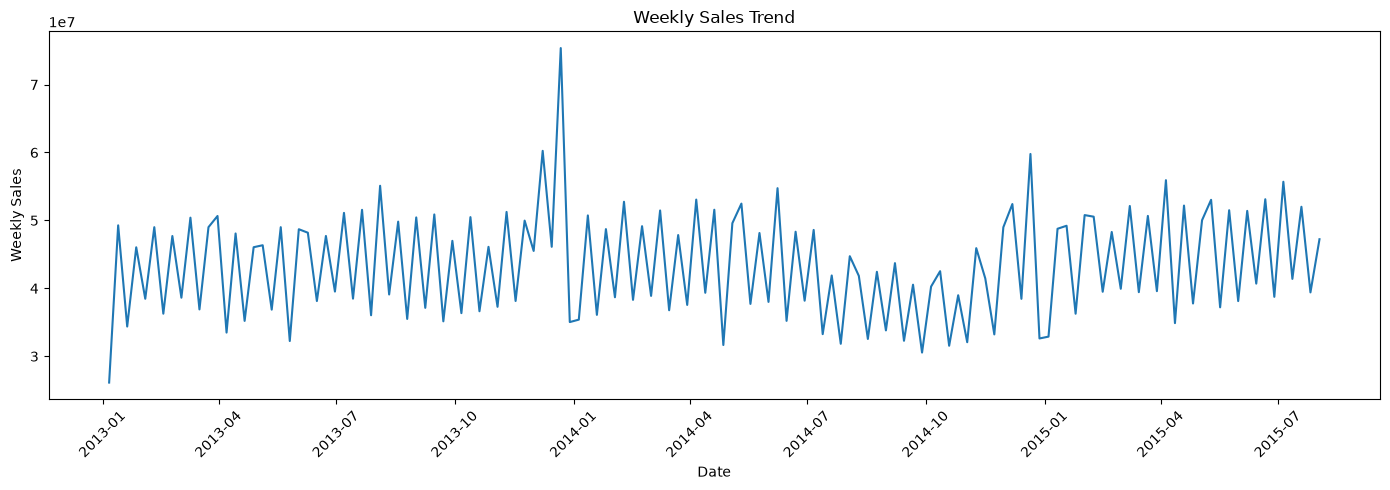

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(weekly_sales.index, weekly_sales.values)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales Trend")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
monthly_sales = daily_total_sales.resample("ME").sum()

print(monthly_sales.head(12))

Date
2013-01-31    180132207
2013-02-28    171534275
2013-03-31    201180369
2013-04-30    183431432
2013-05-31    185411063
2013-06-30    180702351
2013-07-31    208843882
2013-08-31    198042727
2013-09-30    178053963
2013-10-31    187662330
2013-11-30    196170924
2013-12-31    231710561
Freq: ME, Name: Sales, dtype: int64


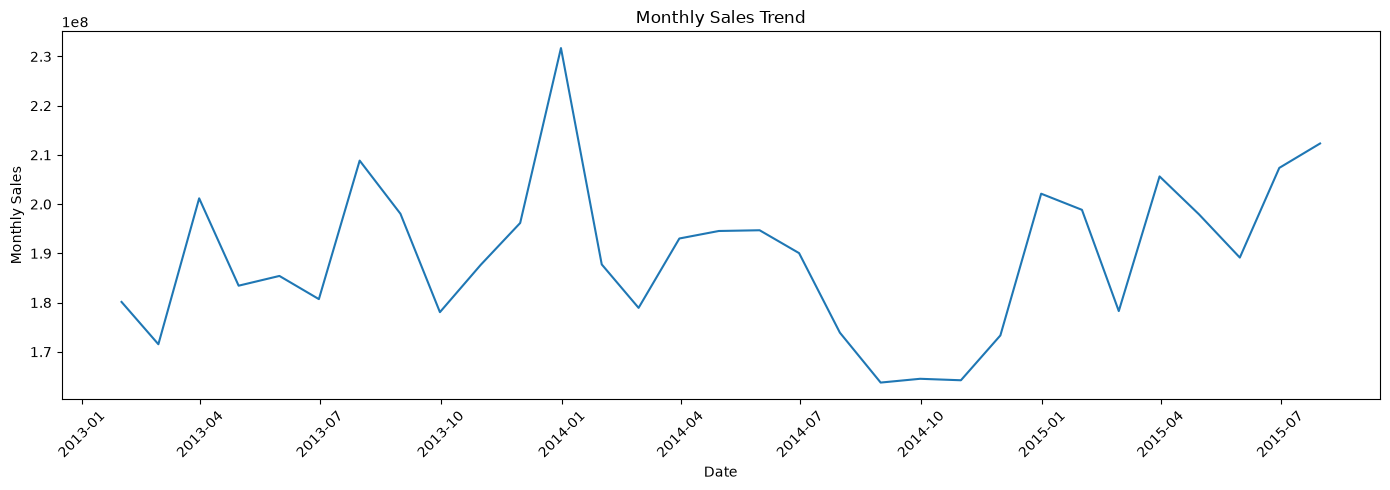

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
customer_sales = open_sales[["Customers", "Sales"]]

print(customer_sales.corr())

           Customers     Sales
Customers   1.000000  0.823597
Sales       0.823597  1.000000


In [ ]:
# 3. Feature Engineering

# We extract useful time-based features from the Date column to help the forecasting model learn seasonal demand patterns.

In [25]:
train["Year"] = train["Date"].dt.year
train["Month"] = train["Date"].dt.month
train["Day"] = train["Date"].dt.day
train["WeekOfYear"] = train["Date"].dt.isocalendar().week.astype(int)

In [26]:
train[["Date", "Year", "Month", "Day", "WeekOfYear"]].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [27]:
train["IsWeekend"] = train["DayOfWeek"].isin([6, 7]).astype(int)

In [28]:
train[["DayOfWeek", "IsWeekend"]].head(10)

,DayOfWeek,IsWeekend
0,5,0
1,5,0
2,5,0
3,5,0
4,5,0
5,5,0
6,5,0
7,5,0
8,5,0
9,5,0


In [29]:
model_data = train[
    [
        "Store",
        "DayOfWeek",
        "Year",
        "Month",
        "Day",
        "WeekOfYear",
        "IsWeekend",
        "Promo",
        "StateHoliday",
        "SchoolHoliday",
        "Sales"
    ]
].copy()

In [30]:
model_data.head()

,Store,DayOfWeek,Year,Month,Day,WeekOfYear,IsWeekend,Promo,StateHoliday,SchoolHoliday,Sales
0,1,5,2015,7,31,31,0,1,0,1,5263
1,2,5,2015,7,31,31,0,1,0,1,6064
2,3,5,2015,7,31,31,0,1,0,1,8314
3,4,5,2015,7,31,31,0,1,0,1,13995
4,5,5,2015,7,31,31,0,1,0,1,4822


In [31]:
print(model_data["StateHoliday"].value_counts())

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [32]:
print(model_data["StateHoliday"].map(type).value_counts())

StateHoliday
<class 'str'>    886137
<class 'int'>    131072
Name: count, dtype: int64


In [33]:
model_data["StateHoliday"] = model_data["StateHoliday"].astype(str)

In [34]:
print(model_data["StateHoliday"].value_counts())

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [35]:
model_data = pd.get_dummies(
    model_data,
    columns=["StateHoliday"],
    dtype=int
)

In [36]:
print(model_data.columns)

Index(['Store', 'DayOfWeek', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend',
       'Promo', 'SchoolHoliday', 'Sales', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c'],
      dtype='str')


In [37]:
model_data.head()

,Store,DayOfWeek,Year,Month,Day,WeekOfYear,IsWeekend,Promo,SchoolHoliday,Sales,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,2015,7,31,31,0,1,1,5263,1,0,0,0
1,2,5,2015,7,31,31,0,1,1,6064,1,0,0,0
2,3,5,2015,7,31,31,0,1,1,8314,1,0,0,0
3,4,5,2015,7,31,31,0,1,1,13995,1,0,0,0
4,5,5,2015,7,31,31,0,1,1,4822,1,0,0,0


In [38]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [39]:
store_features = store[
    ["Store", "StoreType", "Assortment", "CompetitionDistance", "Promo2"]
].copy()

model_data = model_data.merge(
    store_features,
    on="Store",
    how="left"
)

model_data.head()

,Store,DayOfWeek,Year,Month,Day,WeekOfYear,IsWeekend,Promo,SchoolHoliday,Sales,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType,Assortment,CompetitionDistance,Promo2
0,1,5,2015,7,31,31,0,1,1,5263,1,0,0,0,c,a,1270.0,0
1,2,5,2015,7,31,31,0,1,1,6064,1,0,0,0,a,a,570.0,1
2,3,5,2015,7,31,31,0,1,1,8314,1,0,0,0,a,a,14130.0,1
3,4,5,2015,7,31,31,0,1,1,13995,1,0,0,0,c,c,620.0,0
4,5,5,2015,7,31,31,0,1,1,4822,1,0,0,0,a,a,29910.0,0


In [40]:
model_data.isnull().sum()

Store                     0
DayOfWeek                 0
Year                      0
Month                     0
Day                       0
WeekOfYear                0
IsWeekend                 0
Promo                     0
SchoolHoliday             0
Sales                     0
StateHoliday_0            0
StateHoliday_a            0
StateHoliday_b            0
StateHoliday_c            0
StoreType                 0
Assortment                0
CompetitionDistance    2642
Promo2                    0
dtype: int64

In [41]:
median_distance = model_data["CompetitionDistance"].median()

model_data["CompetitionDistance"] = model_data["CompetitionDistance"].fillna(
    median_distance
)

print("Median competition distance:", median_distance)
print("Missing values:", model_data["CompetitionDistance"].isnull().sum())

Median competition distance: 2330.0
Missing values: 0


In [42]:
model_data = pd.get_dummies(
    model_data,
    columns=["StoreType", "Assortment"],
    dtype=int
)

print(model_data.columns)

Index(['Store', 'DayOfWeek', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend',
       'Promo', 'SchoolHoliday', 'Sales', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'CompetitionDistance', 'Promo2',
       'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d',
       'Assortment_a', 'Assortment_b', 'Assortment_c'],
      dtype='str')


In [43]:
model_data.dtypes

Store                    int64
DayOfWeek                int64
Year                     int32
Month                    int32
Day                      int32
WeekOfYear               int64
IsWeekend                int64
Promo                    int64
SchoolHoliday            int64
Sales                    int64
StateHoliday_0           int64
StateHoliday_a           int64
StateHoliday_b           int64
StateHoliday_c           int64
CompetitionDistance    float64
Promo2                   int64
StoreType_a              int64
StoreType_b              int64
StoreType_c              int64
StoreType_d              int64
Assortment_a             int64
Assortment_b             int64
Assortment_c             int64
dtype: object

In [44]:
print("Start date:", train["Date"].min())
print("End date:", train["Date"].max())

Start date: 2013-01-01 00:00:00
End date: 2015-07-31 00:00:00


In [45]:
train_data = model_data[train["Date"] < "2015-06-01"].copy()
validation_data = model_data[train["Date"] >= "2015-06-01"].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))

Training rows: 949194
Validation rows: 68015


In [46]:
id="f7v2m1"
features = [
    "Store",
    "DayOfWeek",
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "IsWeekend",
    "Promo",
    "SchoolHoliday",
    "StateHoliday_0",
    "StateHoliday_a",
    "StateHoliday_b",
    "StateHoliday_c",
    "CompetitionDistance",
    "Promo2",
    "StoreType_a",
    "StoreType_b",
    "StoreType_c",
    "StoreType_d",
    "Assortment_a",
    "Assortment_b",
    "Assortment_c"
]

X_train = train_data[features]
y_train = train_data["Sales"]

X_val = validation_data[features]
y_val = validation_data["Sales"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (949194, 22)
y_train: (949194,)
X_val: (68015, 22)
y_val: (68015,)


In [47]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [49]:
rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [50]:
y_pred = rf_model.predict(X_val)

print(y_pred[:10])

[ 7972.96512125  7374.69843378  9035.73750906 10308.33056515
  6629.17895746  6348.27305827 10353.19705355  7561.10193129
  9141.9300856   7517.94143876]


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1250.5549962696978
RMSE: 1891.150784183298


In [52]:
baseline_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [mae],
    "RMSE": [rmse]
})

baseline_results

,Model,MAE,RMSE
0,Random Forest,1250.554996,1891.150784


In [53]:
forecast_data = train[
    [
        "Store",
        "Date",
        "DayOfWeek",
        "Promo",
        "SchoolHoliday",
        "Sales"
    ]
].copy()

forecast_data = forecast_data.sort_values(
    ["Store", "Date"]
).reset_index(drop=True)

forecast_data.head()

,Store,Date,DayOfWeek,Promo,SchoolHoliday,Sales
0,1,2013-01-01,2,0,1,0
1,1,2013-01-02,3,0,1,5530
2,1,2013-01-03,4,0,1,4327
3,1,2013-01-04,5,0,1,4486
4,1,2013-01-05,6,0,1,4997


In [54]:
forecast_data["Sales_Lag_1"] = (
    forecast_data.groupby("Store")["Sales"].shift(1)
)

forecast_data.head()

,Store,Date,DayOfWeek,Promo,SchoolHoliday,Sales,Sales_Lag_1
0,1,2013-01-01,2,0,1,0,NaN
1,1,2013-01-02,3,0,1,5530,0.0
2,1,2013-01-03,4,0,1,4327,5530.0
3,1,2013-01-04,5,0,1,4486,4327.0
4,1,2013-01-05,6,0,1,4997,4486.0


In [55]:
forecast_data["Sales_Lag_7"] = (
    forecast_data.groupby("Store")["Sales"].shift(7)
)

forecast_data[
    ["Store", "Date", "Sales", "Sales_Lag_1", "Sales_Lag_7"]
].head(10)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7
0,1,2013-01-01,0,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN
2,1,2013-01-03,4327,5530.0,NaN
3,1,2013-01-04,4486,4327.0,NaN
4,1,2013-01-05,4997,4486.0,NaN
5,1,2013-01-06,0,4997.0,NaN
6,1,2013-01-07,7176,0.0,NaN
7,1,2013-01-08,5580,7176.0,0.0
8,1,2013-01-09,5471,5580.0,5530.0
9,1,2013-01-10,4892,5471.0,4327.0


In [56]:
forecast_data["Sales_Rolling_7"] = (
    forecast_data
    .groupby("Store")["Sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

forecast_data[
    ["Store", "Date", "Sales", "Sales_Lag_1", "Sales_Lag_7", "Sales_Rolling_7"]
].head(12)

,Store,Date,Sales,Sales_Lag_1,Sales_Lag_7,Sales_Rolling_7
0,1,2013-01-01,0,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN
5,1,2013-01-06,0,4997.0,NaN,NaN
6,1,2013-01-07,7176,0.0,NaN,NaN
7,1,2013-01-08,5580,7176.0,0.0,3788.000000
8,1,2013-01-09,5471,5580.0,5530.0,4585.142857
9,1,2013-01-10,4892,5471.0,4327.0,4576.714286


In [57]:
forecast_data[
    ["Sales_Lag_1", "Sales_Lag_7", "Sales_Rolling_7"]
].isna().sum()

Sales_Lag_1        1115
Sales_Lag_7        7805
Sales_Rolling_7    7805
dtype: int64

In [58]:
forecast_data = forecast_data.dropna(
    subset=["Sales_Lag_1", "Sales_Lag_7", "Sales_Rolling_7"]
).copy()

forecast_data.shape

(1009404, 9)

In [59]:
forecast_data.columns

Index(['Store', 'Date', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'Sales',
       'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Rolling_7'],
      dtype='str')

In [60]:
forecast_train = forecast_data[
    forecast_data["Date"] < "2015-06-01"
].copy()

forecast_val = forecast_data[
    forecast_data["Date"] >= "2015-06-01"
].copy()

print("Training rows:", len(forecast_train))
print("Validation rows:", len(forecast_val))

Training rows: 941389
Validation rows: 68015


In [61]:
forecast_features = [
    "Store",
    "DayOfWeek",
    "Promo",
    "SchoolHoliday",
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Rolling_7"
]

X_forecast_train = forecast_train[forecast_features]
y_forecast_train = forecast_train["Sales"]

X_forecast_val = forecast_val[forecast_features]
y_forecast_val = forecast_val["Sales"]

print("X_train:", X_forecast_train.shape)
print("y_train:", y_forecast_train.shape)
print("X_val:", X_forecast_val.shape)
print("y_val:", y_forecast_val.shape)

X_train: (941389, 7)
y_train: (941389,)
X_val: (68015, 7)
y_val: (68015,)


In [62]:
from sklearn.ensemble import RandomForestRegressor

forecast_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=2
)

forecast_model.fit(
    X_forecast_train,
    y_forecast_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_l

In [63]:
forecast_pred = forecast_model.predict(X_forecast_val)

forecast_pred[:10]

array([7.18421124e+03, 5.18593127e+03, 5.30979113e+03, 5.25958362e+03,
       7.46553522e+03, 5.42400977e+03, 3.26031636e-01, 3.43581936e+03,
       3.71741484e+03, 3.84273134e+03])

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast_mae = mean_absolute_error(
    y_forecast_val,
    forecast_pred
)

forecast_rmse = np.sqrt(
    mean_squared_error(
        y_forecast_val,
        forecast_pred
    )
)

print("Forecasting MAE:", forecast_mae)
print("Forecasting RMSE:", forecast_rmse)

Forecasting MAE: 761.1885932342932
Forecasting RMSE: 1447.4739095087173


In [65]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest Baseline",
        "Random Forest + Lag Features"
    ],
    "MAE": [
        mae,
        forecast_mae
    ],
    "RMSE": [
        rmse,
        forecast_rmse
    ]
})

model_comparison

,Model,MAE,RMSE
0,Random Forest Baseline,1250.554996,1891.150784
1,Random Forest + Lag Features,761.188593,1447.473910


In [66]:
mae_improvement = (
    (mae - forecast_mae) / mae
) * 100

rmse_improvement = (
    (rmse - forecast_rmse) / rmse
) * 100

print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement: 39.13%
RMSE improvement: 23.46%


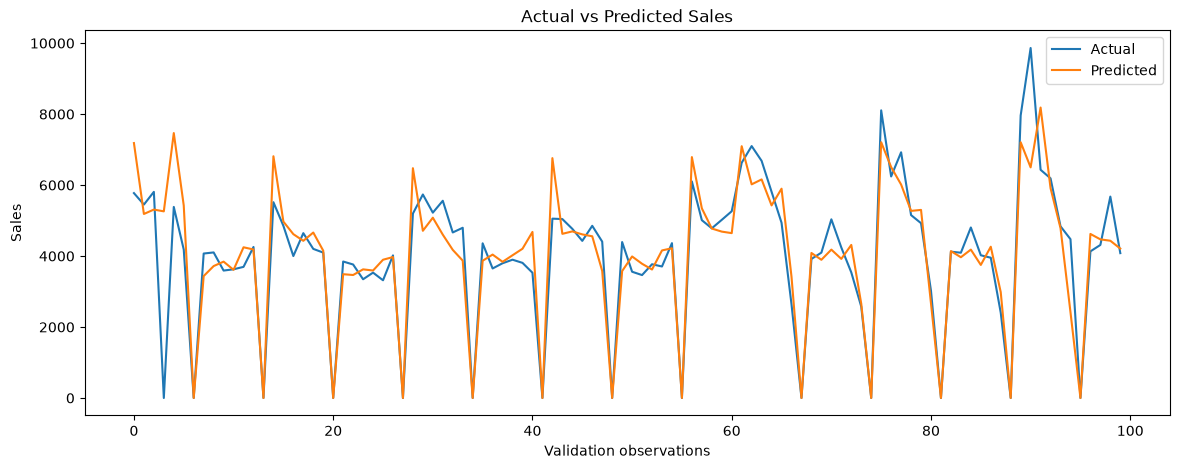

In [67]:
comparison = pd.DataFrame({
    "Actual": y_forecast_val.values,
    "Predicted": forecast_pred
})

comparison.head(100).plot(
    figsize=(14, 5),
    title="Actual vs Predicted Sales"
)

plt.xlabel("Validation observations")
plt.ylabel("Sales")
plt.show()

In [68]:
feature_importance = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": forecast_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,DayOfWeek,0.432321
6,Sales_Rolling_7,0.282879
4,Sales_Lag_1,0.098651
5,Sales_Lag_7,0.086500
2,Promo,0.080561
3,SchoolHoliday,0.010459
0,Store,0.008630


In [69]:
feature_importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [70]:
forecast_errors = y_forecast_val.values - forecast_pred

print("Mean Error:", forecast_errors.mean())
print("Mean Absolute Error:", np.abs(forecast_errors).mean())
print("Error Standard Deviation:", forecast_errors.std())

Mean Error: 48.64685188800577
Mean Absolute Error: 761.1885932342932
Error Standard Deviation: 1446.6562143473607


In [72]:
inventory_data = pd.DataFrame({
    "Store": forecast_val["Store"].values,
    "Date": forecast_val["Date"].values,
    "Actual_Sales": y_forecast_val.values,
    "Predicted_Sales": forecast_pred
})

inventory_data["Forecast_Error"] = (
    inventory_data["Actual_Sales"]
    - inventory_data["Predicted_Sales"]
)

store_error_stats = (
    inventory_data
    .groupby("Store")["Forecast_Error"]
    .agg(["mean", "std"])
    .reset_index()
)

store_error_stats.head(10)

,Store,mean,std
0,1,-184.631973,916.754244
1,2,129.205121,816.693876
2,3,180.010393,1612.942723
3,4,189.019088,1478.993571
4,5,47.466018,387.868072
5,6,-20.987755,480.581192
6,7,509.142545,1266.618174
7,8,240.196309,1004.916609
8,9,8.557561,1648.469281
9,10,22.615801,925.840754


In [73]:
z_score = 1.645

store_error_stats["Safety_Stock"] = (
    z_score * store_error_stats["std"]
)

store_error_stats.head(10)

,Store,mean,std,Safety_Stock
0,1,-184.631973,916.754244,1508.060731
1,2,129.205121,816.693876,1343.461426
2,3,180.010393,1612.942723,2653.290780
3,4,189.019088,1478.993571,2432.944424
4,5,47.466018,387.868072,638.042979
5,6,-20.987755,480.581192,790.556061
6,7,509.142545,1266.618174,2083.586897
7,8,240.196309,1004.916609,1653.087821
8,9,8.557561,1648.469281,2711.731967
9,10,22.615801,925.840754,1523.008041


In [74]:
store_demand = (
    forecast_train
    .groupby("Store")["Sales"]
    .mean()
    .reset_index(name="Average_Daily_Demand")
)

store_demand.head(10)

,Store,Average_Daily_Demand
0,1,3957.735698
1,2,4113.399314
2,3,5719.958810
3,4,7988.559497
4,5,3860.234554
5,6,4601.336384
6,7,7292.538902
7,8,4548.030892
8,9,5364.457666
9,10,4599.304348


In [75]:
lead_time_days = 1

inventory_policy = store_demand.merge(
    store_error_stats[["Store", "Safety_Stock"]],
    on="Store",
    how="left"
)

inventory_policy["Reorder_Point"] = (
    inventory_policy["Average_Daily_Demand"] * lead_time_days
    + inventory_policy["Safety_Stock"]
)

inventory_policy.head(10)

,Store,Average_Daily_Demand,Safety_Stock,Reorder_Point
0,1,3957.735698,1508.060731,5465.796429
1,2,4113.399314,1343.461426,5456.860739
2,3,5719.958810,2653.290780,8373.249590
3,4,7988.559497,2432.944424,10421.503921
4,5,3860.234554,638.042979,4498.277532
5,6,4601.336384,790.556061,5391.892446
6,7,7292.538902,2083.586897,9376.125799
7,8,4548.030892,1653.087821,6201.118714
8,9,5364.457666,2711.731967,8076.189633
9,10,4599.304348,1523.008041,6122.312389


In [76]:
inventory_policy.to_csv(
    "../data/inventory_policy.csv",
    index=False
)

print("Inventory policy saved.")

Inventory policy saved.


In [77]:
inventory_policy["Safety_Stock_Ratio"] = (
    inventory_policy["Safety_Stock"]
    / inventory_policy["Average_Daily_Demand"]
)

inventory_policy[[
    "Store",
    "Average_Daily_Demand",
    "Safety_Stock",
    "Reorder_Point",
    "Safety_Stock_Ratio"
]].sort_values(
    "Safety_Stock_Ratio",
    ascending=False
).head(10)

,Store,Average_Daily_Demand,Safety_Stock,Reorder_Point,Safety_Stock_Ratio
908,909,8592.065217,11576.622794,20168.688011,1.347362
182,183,3829.134783,5080.230843,8909.365626,1.326731
291,292,4754.100686,6081.675385,10835.776071,1.279248
875,876,7556.360412,8067.985055,15624.345467,1.067708
635,636,4796.623188,3668.657095,8465.280283,0.764842
574,575,4401.965217,2981.581001,7383.546219,0.677330
692,693,5464.343249,3509.333313,8973.676562,0.642224
12,13,4099.802899,2629.262251,6729.065150,0.641314
788,789,2759.840961,1766.655054,4526.496015,0.640129
694,695,4432.575515,2803.519555,7236.095070,0.632481


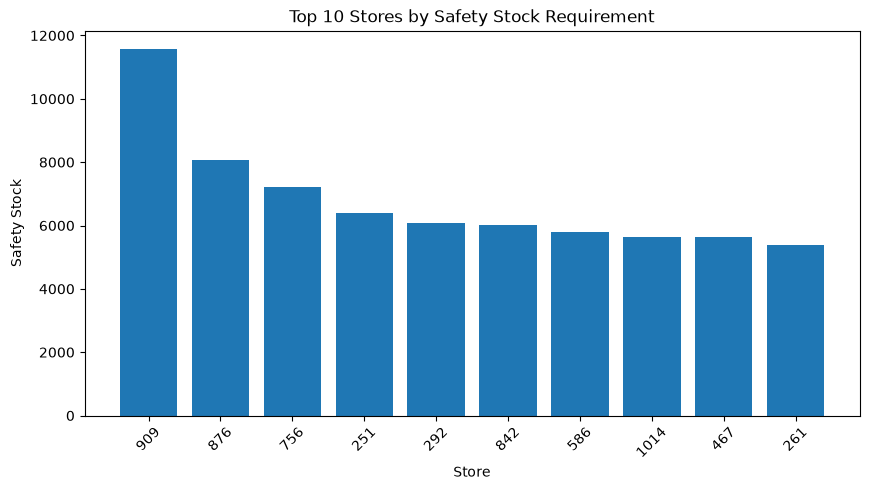

In [78]:
top_safety_stock = inventory_policy.nlargest(
    10,
    "Safety_Stock"
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_safety_stock["Store"].astype(str),
    top_safety_stock["Safety_Stock"]
)

plt.xlabel("Store")
plt.ylabel("Safety Stock")
plt.title("Top 10 Stores by Safety Stock Requirement")
plt.xticks(rotation=45)

plt.show()

In [79]:
final_inventory = inventory_policy.copy()

final_inventory["Average_Daily_Demand"] = (
    final_inventory["Average_Daily_Demand"].round(0)
)

final_inventory["Safety_Stock"] = (
    final_inventory["Safety_Stock"].round(0)
)

final_inventory["Reorder_Point"] = (
    final_inventory["Reorder_Point"].round(0)
)

final_inventory["Safety_Stock_Ratio"] = (
    final_inventory["Safety_Stock_Ratio"].round(2)
)

final_inventory.head(10)

,Store,Average_Daily_Demand,Safety_Stock,Reorder_Point,Safety_Stock_Ratio
0,1,3958.0,1508.0,5466.0,0.38
1,2,4113.0,1343.0,5457.0,0.33
2,3,5720.0,2653.0,8373.0,0.46
3,4,7989.0,2433.0,10422.0,0.30
4,5,3860.0,638.0,4498.0,0.17
5,6,4601.0,791.0,5392.0,0.17
6,7,7293.0,2084.0,9376.0,0.29
7,8,4548.0,1653.0,6201.0,0.36
8,9,5364.0,2712.0,8076.0,0.51
9,10,4599.0,1523.0,6122.0,0.33


In [80]:
final_inventory.to_csv(
    "../data/final_inventory_policy.csv",
    index=False
)

print("Final inventory policy saved.")

Final inventory policy saved.


In [81]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest Baseline",
        "Random Forest + Lag Features"
    ],
    "MAE": [
        1250.55,
        761.19
    ],
    "RMSE": [
        1891.15,
        1447.47
    ]
})

model_comparison

,Model,MAE,RMSE
0,Random Forest Baseline,1250.55,1891.15
1,Random Forest + Lag Features,761.19,1447.47


In [82]:
model_comparison.to_csv(
    "../data/model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


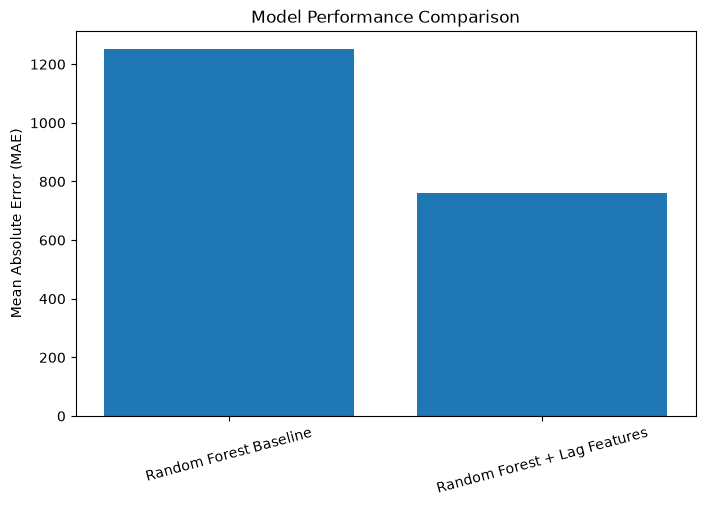

In [83]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Model Performance Comparison")
plt.xticks(rotation=15)

plt.show()

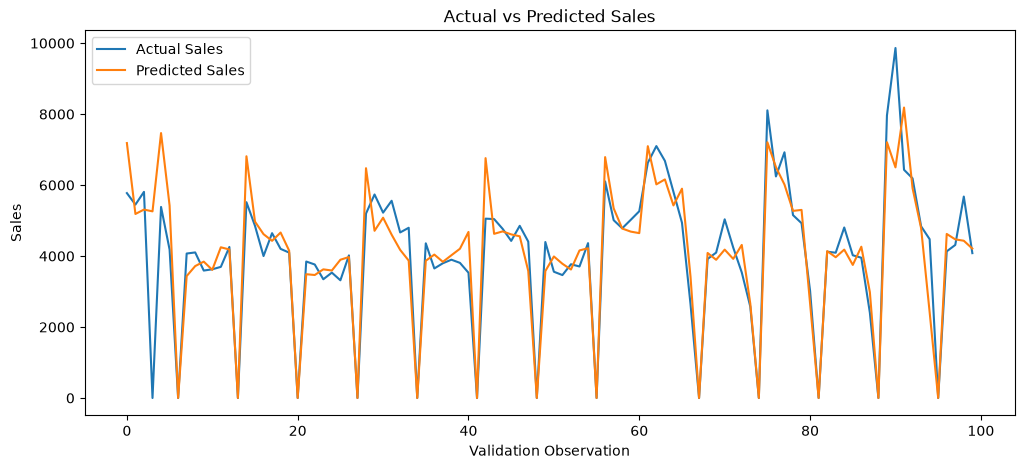

In [84]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_forecast_val.values[:100],
    label="Actual Sales"
)

plt.plot(
    forecast_pred[:100],
    label="Predicted Sales"
)

plt.xlabel("Validation Observation")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()

plt.show()

In [85]:
forecast_results = forecast_val[
    ["Store", "Date"]
].copy()

forecast_results["Actual_Sales"] = y_forecast_val.values
forecast_results["Predicted_Sales"] = forecast_pred

forecast_results.head(10)

,Store,Date,Actual_Sales,Predicted_Sales
881,1,2015-06-01,5774,7184.211244
882,1,2015-06-02,5450,5185.931265
883,1,2015-06-03,5809,5309.791125
884,1,2015-06-04,0,5259.583618
885,1,2015-06-05,5384,7465.535216
886,1,2015-06-06,4183,5424.009769
887,1,2015-06-07,0,0.326032
888,1,2015-06-08,4071,3435.819358
889,1,2015-06-09,4102,3717.414836
890,1,2015-06-10,3591,3842.731340


In [86]:
forecast_results.to_csv(
    "../data/forecast_results.csv",
    index=False
)

print("Forecast results saved.")



Forecast results saved.


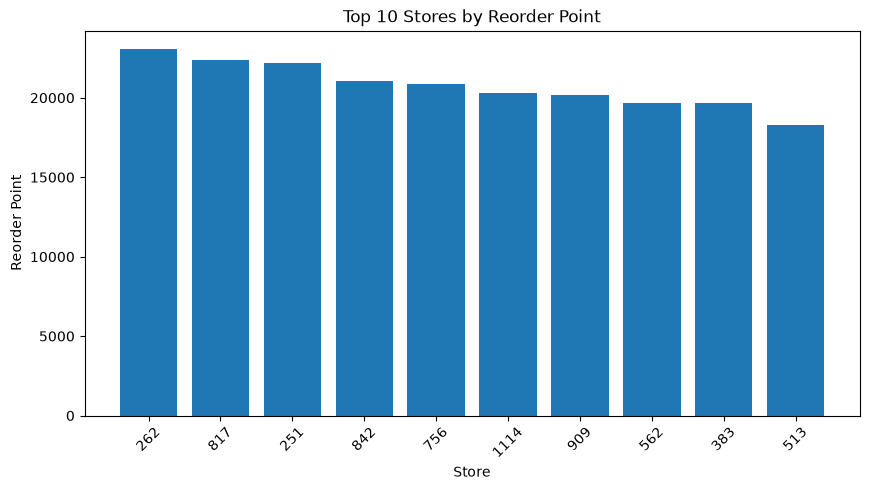

In [87]:
top_reorder_points = inventory_policy.nlargest(
    10,
    "Reorder_Point"
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_reorder_points["Store"].astype(str),
    top_reorder_points["Reorder_Point"]
)

plt.xlabel("Store")
plt.ylabel("Reorder Point")
plt.title("Top 10 Stores by Reorder Point")
plt.xticks(rotation=45)

plt.show()

In [88]:
final_inventory.to_csv(
    "../data/final_inventory_policy.csv",
    index=False
)

print("Final inventory policy updated.")

Final inventory policy updated.


In [89]:
feature_importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [90]:
project_summary = pd.DataFrame({
    "Metric": [
        "Training Rows",
        "Validation Rows",
        "Baseline MAE",
        "Forecasting MAE",
        "Baseline RMSE",
        "Forecasting RMSE",
        "MAE Improvement"
    ],
    "Value": [
        len(forecast_train),
        len(forecast_val),
        1250.55,
        761.19,
        1891.15,
        1447.47,
        "39.13%"
    ]
})

project_summary

,Metric,Value
0,Training Rows,941389
1,Validation Rows,68015
2,Baseline MAE,1250.55
3,Forecasting MAE,761.19
4,Baseline RMSE,1891.15
5,Forecasting RMSE,1447.47
6,MAE Improvement,39.13%


In [91]:
project_summary.to_csv(
    "../data/project_summary.csv",
    index=False
)

print("Project summary saved.")

Project summary saved.


In [ ]:
# # 6. Project Results

# ## Forecasting Performance

# A Random Forest model with historical lag features was evaluated using a chronological validation split.

# | Model | MAE | RMSE |
# |---|---:|---:|
# | Random Forest Baseline | 1250.55 | 1891.15 |
# | Random Forest + Lag Features | 761.19 | 1447.47 |

# The lag-feature model reduced validation MAE by approximately **39.13%** compared with the baseline.

# ## Inventory Optimization

# The forecasting errors were used to estimate safety stock for each store.

# The inventory policy uses:

# - Average daily demand
# - Forecast error variability
# - 95% service-level z-score assumption
# - 1-day replenishment lead time

# The resulting **reorder point** provides an estimated inventory threshold at which replenishment should be triggered.

# Key Outputs

# - `forecast_results.csv` — actual vs predicted sales
# - `feature_importance.csv` — model feature importance
# - `model_comparison.csv` — model performance comparison
# - `inventory_policy.csv` — store-level inventory policy
# - `final_inventory_policy.csv` — rounded final inventory policy
# - `project_summary.csv` — key project metrics

# Limitations

# - The current forecasting model does not use the `Open` feature.
# - Closed-store days can therefore produce non-zero predictions.
# - The inventory calculation assumes a 1-day lead time.
# - Safety stock uses a simplified normal-error assumption.
# - A production system would require actual lead-time data, service-level requirements, current inventory, and replenishment constraints.